In [1]:
from google.colab import files
uploaded = files.upload()

Saving car_prices_cleaned (1).csv to car_prices_cleaned (1).csv


In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.8 MB/s eta 0:00:00


ADVANCED MODEL WITH STACKING & FEATURE ENGINEERING
Original dataset shape: (2229, 14)

ADVANCED FEATURE ENGINEERING
Creating advanced interaction features...
After feature engineering: (2229, 41)
After dropping NaN: (2226, 41)

TRAIN/TEST SPLIT
Train set: (1780, 34)
Test set: (446, 34)
Using log-transformed target: False

TARGET ENCODING WITH K-FOLD
K-Fold encoding brand...
K-Fold encoding body_type...
K-Fold encoding fuel_type_simple...
K-Fold encoding model...
Final train shape: (1780, 34)
Final test shape: (446, 34)

APPLYING QUANTILE TRANSFORMATION
✓ Using QuantileTransformer for better distribution handling

BUILDING STACKING ENSEMBLE
Using OPTIMIZED hyperparameters from your tuning results:
  XGBoost: n_estimators=300, lr=0.06, depth=6
  GBR: n_estimators=200, lr=0.1, depth=5
  RandomForest: n_estimators=300, depth=20
Training Stacking Ensemble...

STACKING ENSEMBLE RESULTS
Train MAE: 5,918 TND | Test MAE: 14,654 TND
Train RMSE: 8,163 TND | Test RMSE: 23,016 TND
Train R²: 0.9887 

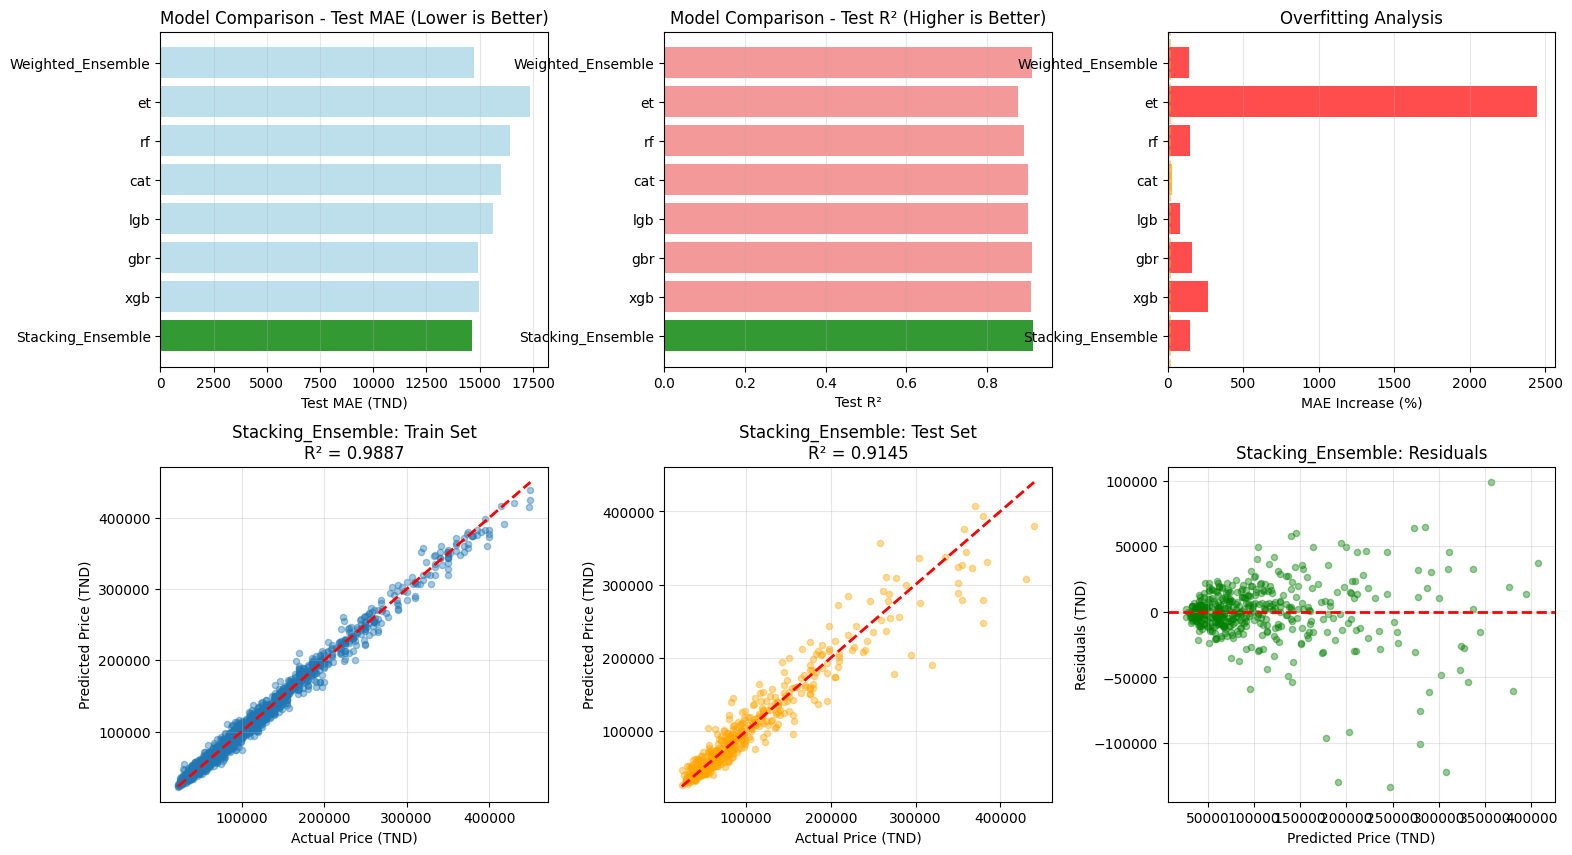

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import RobustScaler, QuantileTransformer
import lightgbm as lgb
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: Load data
# ============================================
print("="*60)
print("ADVANCED MODEL WITH STACKING & FEATURE ENGINEERING")
print("="*60)

df_clean = pd.read_csv('car_prices_cleaned (1).csv')
print(f"Original dataset shape: {df_clean.shape}")

# ============================================
# STEP 2: ENHANCED Feature Engineering
# ============================================
print("\n" + "="*60)
print("ADVANCED FEATURE ENGINEERING")
print("="*60)

def extract_year(year_str):
    if pd.isna(year_str):
        return None
    year_str = str(year_str).strip()
    if '.' in year_str:
        parts = year_str.split('.')
        if len(parts) == 2:
            try:
                return int(parts[1])
            except:
                return None
    return None

def extract_month(year_str):
    if pd.isna(year_str):
        return None
    year_str = str(year_str)
    if '.' in year_str:
        return int(year_str.split('.')[0])
    return None

def extract_fiscal_power(value):
    if pd.isna(value):
        return None
    import re
    numbers = re.findall(r'\d+', str(value))
    if numbers:
        return float(numbers[0])
    return None

# Basic features
df_clean['year_extracted'] = df_clean['registration_year'].apply(extract_year)
df_clean['month'] = df_clean['registration_year'].apply(extract_month)
df_clean['car_age'] = 2025 - df_clean['year_extracted']
df_clean['puissance_fiscale'] = df_clean['puissance_fiscale'].apply(extract_fiscal_power)
df_clean['kilometrage'] = df_clean['kilometrage'].astype(str).str.replace(' km', '').str.replace(' ', '').astype(float)

# Binary encoding
df_clean['is_new'] = (df_clean['new'] == 'yes').astype(int)
df_clean['climatisation_binary'] = (df_clean['climatisation'].str.lower() == 'yes').astype(int)
df_clean['transmission_binary'] = (df_clean['transmission'] == 'Automatique').astype(int)

# Standardize brands
brand_mapping = {
    'bmw': 'BMW', 'mercedes-benz': 'Mercedes-Benz', 'hyundai': 'Hyundai',
    'kia': 'KIA', 'peugeot': 'Peugeot', 'toyota': 'Toyota',
    'volkswagen': 'Volkswagen', 'skoda': 'Skoda', 'suzuki': 'Suzuki',
    'renault': 'Renault', 'audi': 'Audi', 'volvo': 'Volvo',
    'seat': 'Seat', 'honda': 'Honda', 'fiat': 'Fiat', 'citroen': 'Citroën',
    'porsche': 'Porsche', 'mg': 'MG'
}
df_clean['brand'] = df_clean['brand'].replace(brand_mapping)

def simplify_fuel_type(fuel):
    fuel = str(fuel).lower()
    if 'electrique' in fuel:
        return 'electrique'
    elif 'hybride' in fuel:
        return 'hybride'
    elif 'diesel' in fuel:
        return 'diesel'
    else:
        return 'essence'

df_clean['fuel_type_simple'] = df_clean['fuel_type'].apply(simplify_fuel_type)

# ============================================
# NEW: ADVANCED INTERACTION FEATURES
# ============================================
print("Creating advanced interaction features...")

# Age-based features
df_clean['km_per_year'] = df_clean['kilometrage'] / (df_clean['car_age'] + 1)
df_clean['age_squared'] = df_clean['car_age'] ** 2
df_clean['age_cubed'] = df_clean['car_age'] ** 3
df_clean['log_km'] = np.log1p(df_clean['kilometrage'])
df_clean['sqrt_km'] = np.sqrt(df_clean['kilometrage'])

# Power-based features
df_clean['power_per_seat'] = df_clean['puissance_fiscale'] / df_clean['seats']
df_clean['power_squared'] = df_clean['puissance_fiscale'] ** 2
df_clean['log_power'] = np.log1p(df_clean['puissance_fiscale'])

# Age-Power interaction
df_clean['age_power_interaction'] = df_clean['car_age'] * df_clean['puissance_fiscale']
df_clean['km_power_interaction'] = df_clean['log_km'] * df_clean['puissance_fiscale']

# Depreciation rate (km/age ratio)
df_clean['depreciation_rate'] = df_clean['kilometrage'] / ((df_clean['car_age'] + 1) * df_clean['puissance_fiscale'])

# Luxury brand indicator
luxury_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Porsche', 'Land Rover', 'Jaguar']
df_clean['is_luxury'] = df_clean['brand'].isin(luxury_brands).astype(int)

# Premium features interaction
df_clean['luxury_new'] = df_clean['is_luxury'] * df_clean['is_new']
df_clean['luxury_auto'] = df_clean['is_luxury'] * df_clean['transmission_binary']

# New car features
df_clean['new_low_km'] = ((df_clean['is_new'] == 1) & (df_clean['kilometrage'] < 1000)).astype(int)
df_clean['is_very_new'] = (df_clean['car_age'] <= 1).astype(int)

# High mileage indicator
df_clean['high_mileage'] = (df_clean['kilometrage'] > 150000).astype(int)

# Electric/Hybrid premium
df_clean['is_electric_hybrid'] = df_clean['fuel_type_simple'].isin(['electrique', 'hybride']).astype(int)
df_clean['electric_new'] = df_clean['is_electric_hybrid'] * df_clean['is_new']

# Binned features (can capture non-linear relationships)
# Use include_lowest=True and handle values outside ranges
df_clean['age_bin'] = pd.cut(df_clean['car_age'],
                              bins=[-1, 2, 5, 10, 100],
                              labels=[0, 1, 2, 3],
                              include_lowest=True).fillna(3).astype(int)

df_clean['km_bin'] = pd.cut(df_clean['kilometrage'],
                             bins=[-1, 50000, 100000, 150000, 500000],
                             labels=[0, 1, 2, 3],
                             include_lowest=True).fillna(3).astype(int)

df_clean['power_bin'] = pd.cut(df_clean['puissance_fiscale'],
                                bins=[-1, 5, 8, 12, 100],
                                labels=[0, 1, 2, 3],
                                include_lowest=True).fillna(3).astype(int)

print(f"After feature engineering: {df_clean.shape}")
df_clean = df_clean.dropna(subset=['price', 'puissance_fiscale', 'year_extracted', 'month'])
print(f"After dropping NaN: {df_clean.shape}")

# ============================================
# STEP 3: Train/Test Split
# ============================================
print("\n" + "="*60)
print("TRAIN/TEST SPLIT")
print("="*60)

target = 'price'
categorical_cols = ['brand', 'body_type', 'fuel_type_simple', 'model']
numeric_cols = ['kilometrage', 'seats', 'puissance_fiscale', 'car_age', 'month',
                'km_per_year', 'age_squared', 'age_cubed', 'log_km', 'sqrt_km',
                'power_per_seat', 'power_squared', 'log_power',
                'age_power_interaction', 'km_power_interaction', 'depreciation_rate']
binary_cols = ['is_new', 'climatisation_binary', 'transmission_binary', 'is_luxury',
               'new_low_km', 'is_very_new', 'high_mileage', 'is_electric_hybrid',
               'electric_new', 'luxury_new', 'luxury_auto',
               'age_bin', 'km_bin', 'power_bin']

feature_cols = categorical_cols + numeric_cols + binary_cols
df_model = df_clean[feature_cols + [target]].copy()

X = df_model.drop('price', axis=1)
y = df_model['price']

# Log transform target to handle skewness
y_log = np.log1p(y)
use_log_target = False

# Stratified split
y_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.2, random_state=42, stratify=y_bins
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Using log-transformed target: {use_log_target}")

# ============================================
# STEP 4: Target Encoding with K-Fold
# ============================================
print("\n" + "="*60)
print("TARGET ENCODING WITH K-FOLD")
print("="*60)

def target_encode_kfold(train_data, test_data, cat_col, target_col, n_splits=5, smoothing=50):
    """K-Fold target encoding to reduce overfitting"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_encoded = np.zeros(len(train_data))

    global_mean = train_data[target_col].mean()

    # K-Fold encoding for train
    for train_idx, val_idx in kf.split(train_data):
        train_fold = train_data.iloc[train_idx]
        val_fold = train_data.iloc[val_idx]

        agg = train_fold.groupby(cat_col)[target_col].agg(['mean', 'count'])
        smoothed_means = (agg['mean'] * agg['count'] + global_mean * smoothing) / (agg['count'] + smoothing)

        train_encoded[val_idx] = val_fold[cat_col].map(smoothed_means).fillna(global_mean)

    # Full train encoding for test
    agg = train_data.groupby(cat_col)[target_col].agg(['mean', 'count'])
    smoothed_means = (agg['mean'] * agg['count'] + global_mean * smoothing) / (agg['count'] + smoothing)
    test_encoded = test_data[cat_col].map(smoothed_means).fillna(global_mean)

    return train_encoded, test_encoded

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

train_with_target = X_train.copy()
train_with_target['price'] = y_train_log if use_log_target else y_train

for col in categorical_cols:
    print(f"K-Fold encoding {col}...")
    train_encoded, test_encoded = target_encode_kfold(
        train_with_target, X_test, col, 'price', n_splits=5, smoothing=50
    )

    X_train_encoded[f'{col}_encoded'] = train_encoded
    X_test_encoded[f'{col}_encoded'] = test_encoded

X_train_encoded = X_train_encoded.drop(categorical_cols, axis=1)
X_test_encoded = X_test_encoded.drop(categorical_cols, axis=1)

print(f"Final train shape: {X_train_encoded.shape}")
print(f"Final test shape: {X_test_encoded.shape}")




# ============================================
# STEP 5: Advanced Scaling with QuantileTransformer
# ============================================
print("\n" + "="*60)
print("APPLYING QUANTILE TRANSFORMATION")
print("="*60)

# Use QuantileTransformer for better distribution handling
scaler = QuantileTransformer(output_distribution='normal', random_state=42)
cols_to_scale = numeric_cols + [f'{col}_encoded' for col in categorical_cols]

X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train_encoded[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test_encoded[cols_to_scale])

print("✓ Using QuantileTransformer for better distribution handling")




X_train_scaled.to_csv("Xtrain.csv", index=False)
X_test_scaled.to_csv("Xtest.csv", index=False)
y_train.to_csv("Ytrain.csv", index=False)
y_test.to_csv("Ytest.csv", index=False)
y_train_log.to_csv("Ytrain_log.csv", index=False)
y_test_log.to_csv("Ytest_log.csv", index=False)
from google.colab import files

# Assuming the file is already created
files.download("Xtrain.csv")
files.download("Xtest.csv")
files.download("Ytrain.csv")
files.download("Ytest.csv")
files.download("Ytrain_log.csv")
files.download("Ytest_log.csv")
# ============================================
# STEP 6: Build Stacking Ensemble
# ============================================
print("\n" + "="*60)
print("BUILDING STACKING ENSEMBLE")
print("="*60)

# Define base models with YOUR OPTIMIZED hyperparameters
base_models = [
    ('xgb', xgb.XGBRegressor(
        n_estimators=300,  # From your tuning
        learning_rate=0.06,  # From your tuning
        max_depth=6,  # From your tuning
        subsample=0.8,  # From your tuning
        colsample_bytree=0.8,  # From your tuning
    )),
    ('gbr', GradientBoostingRegressor(
        n_estimators=200,  # From your tuning
        learning_rate=0.1,  # From your tuning
        max_depth=5,  # From your tuning
        min_samples_split=5,
        subsample=0.8,
        random_state=42
    )),
    ('lgb', lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.06,
        max_depth=6,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=2.0,
        random_state=42,
        verbose=-1
    )),
    ('cat', CatBoostRegressor(
        iterations=300,
        learning_rate=0.06,
        depth=6,
        l2_leaf_reg=5.0,
        random_state=42,
        verbose=0
    )),
    ('rf', RandomForestRegressor(
        n_estimators=300,  # From your tuning
        max_depth=20,  # From your tuning
        min_samples_split=2,  # From your tuning
        min_samples_leaf=1,  # From your tuning
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )),
    ('et', ExtraTreesRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
]

print("Using OPTIMIZED hyperparameters from your tuning results:")
print("  XGBoost: n_estimators=300, lr=0.06, depth=6")
print("  GBR: n_estimators=200, lr=0.1, depth=5")
print("  RandomForest: n_estimators=300, depth=20")

# Meta-model (final estimator)
meta_model = Ridge(alpha=1.0, random_state=42)

# Create stacking regressor
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

print("Training Stacking Ensemble...")
y_train_use = y_train_log if use_log_target else y_train
stacking_model.fit(X_train_scaled, y_train_use)

# Predictions
y_train_pred_log = stacking_model.predict(X_train_scaled)
y_test_pred_log = stacking_model.predict(X_test_scaled)

# Convert back from log if needed
if use_log_target:
    y_train_pred = np.expm1(y_train_pred_log)
    y_test_pred = np.expm1(y_test_pred_log)
else:
    y_train_pred = y_train_pred_log
    y_test_pred = y_test_pred_log

# ============================================
# STEP 7: Evaluate Stacking Model
# ============================================
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

mae_diff = test_mae - train_mae
mae_diff_pct = (mae_diff / train_mae) * 100
r2_diff = train_r2 - test_r2

print("\n" + "="*60)
print("STACKING ENSEMBLE RESULTS")
print("="*60)
print(f"Train MAE: {train_mae:,.0f} TND | Test MAE: {test_mae:,.0f} TND")
print(f"Train RMSE: {train_rmse:,.0f} TND | Test RMSE: {test_rmse:,.0f} TND")
print(f"Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
print(f"Overfitting: {mae_diff_pct:+.1f}% MAE increase, {r2_diff:+.4f} R² drop")

# ============================================
# STEP 8: Train Individual Base Models + Weighted Ensemble
# ============================================
print("\n" + "="*60)
print("TRAINING INDIVIDUAL BASE MODELS")
print("="*60)

results = {'Stacking_Ensemble': {
    'train_mae': train_mae,
    'test_mae': test_mae,
    'train_r2': train_r2,
    'test_r2': test_r2,
    'mae_diff_pct': mae_diff_pct,
    'y_train_pred': y_train_pred,
    'y_test_pred': y_test_pred
}}

# Store predictions for weighted ensemble
train_preds = []
test_preds = []
model_weights = []

for name, model in base_models:
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train_use)

    y_train_pred_log_base = model.predict(X_train_scaled)
    y_test_pred_log_base = model.predict(X_test_scaled)

    if use_log_target:
        y_train_pred_base = np.expm1(y_train_pred_log_base)
        y_test_pred_base = np.expm1(y_test_pred_log_base)
    else:
        y_train_pred_base = y_train_pred_log_base
        y_test_pred_base = y_test_pred_log_base

    train_mae_base = mean_absolute_error(y_train, y_train_pred_base)
    test_mae_base = mean_absolute_error(y_test, y_test_pred_base)
    train_r2_base = r2_score(y_train, y_train_pred_base)
    test_r2_base = r2_score(y_test, y_test_pred_base)

    # Calculate CV score for weighting
    cv_scores = cross_val_score(model, X_train_scaled, y_train_use,
                                 cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_mae = -cv_scores.mean()

    # Weight is inverse of CV MAE (better models get higher weight)
    weight = 1.0 / cv_mae
    model_weights.append(weight)

    train_preds.append(y_train_pred_base)
    test_preds.append(y_test_pred_base)

    results[name] = {
        'train_mae': train_mae_base,
        'test_mae': test_mae_base,
        'train_r2': train_r2_base,
        'test_r2': test_r2_base,
        'mae_diff_pct': ((test_mae_base - train_mae_base) / train_mae_base) * 100,
        'cv_mae': cv_mae,
        'weight': weight,
        'y_train_pred': y_train_pred_base,
        'y_test_pred': y_test_pred_base
    }

    print(f"  Train MAE: {train_mae_base:,.0f} | Test MAE: {test_mae_base:,.0f}")
    print(f"  Train R²: {train_r2_base:.4f} | Test R²: {test_r2_base:.4f}")
    print(f"  CV MAE: {cv_mae:,.0f} | Weight: {weight:.6f}")

# ============================================
# STEP 8.5: Weighted Ensemble (Better than simple averaging)
# ============================================
print("\n" + "="*60)
print("CREATING WEIGHTED ENSEMBLE")
print("="*60)

# Normalize weights to sum to 1
model_weights = np.array(model_weights)
normalized_weights = model_weights / model_weights.sum()

print("Model Weights (based on CV performance):")
for i, (name, _) in enumerate(base_models):
    print(f"  {name}: {normalized_weights[i]:.4f}")

# Weighted average
weighted_train_pred = np.average(train_preds, axis=0, weights=normalized_weights)
weighted_test_pred = np.average(test_preds, axis=0, weights=normalized_weights)

weighted_train_mae = mean_absolute_error(y_train, weighted_train_pred)
weighted_test_mae = mean_absolute_error(y_test, weighted_test_pred)
weighted_train_r2 = r2_score(y_train, weighted_train_pred)
weighted_test_r2 = r2_score(y_test, weighted_test_pred)

results['Weighted_Ensemble'] = {
    'train_mae': weighted_train_mae,
    'test_mae': weighted_test_mae,
    'train_r2': weighted_train_r2,
    'test_r2': weighted_test_r2,
    'mae_diff_pct': ((weighted_test_mae - weighted_train_mae) / weighted_train_mae) * 100,
    'y_train_pred': weighted_train_pred,
    'y_test_pred': weighted_test_pred
}

print(f"\nWeighted Ensemble Results:")
print(f"  Train MAE: {weighted_train_mae:,.0f} | Test MAE: {weighted_test_mae:,.0f}")
print(f"  Train R²: {weighted_train_r2:.4f} | Test R²: {weighted_test_r2:.4f}")
print(f"  Overfitting: {results['Weighted_Ensemble']['mae_diff_pct']:+.1f}%")

# ============================================
# STEP 9: Model Comparison
# ============================================
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train MAE': [results[m]['train_mae'] for m in results.keys()],
    'Test MAE': [results[m]['test_mae'] for m in results.keys()],
    'Overfit %': [results[m]['mae_diff_pct'] for m in results.keys()],
    'Train R²': [results[m]['train_r2'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('Test MAE')
print("\n" + comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test MAE: {results[best_model_name]['test_mae']:,.0f} TND")
print(f"   Test R²: {results[best_model_name]['test_r2']:.4f}")

# ============================================
# STEP 10: Visualizations
# ============================================
print("\n" + "="*60)
print("CREATING VISUALIZATIONS")
print("="*60)

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Model Comparison - Test MAE
ax1 = fig.add_subplot(gs[0, 0])
models_list = list(results.keys())
test_maes = [results[m]['test_mae'] for m in models_list]
colors_mae = ['green' if m == best_model_name else 'lightblue' for m in models_list]
ax1.barh(models_list, test_maes, color=colors_mae, alpha=0.8)
ax1.set_xlabel('Test MAE (TND)')
ax1.set_title('Model Comparison - Test MAE (Lower is Better)')
ax1.grid(axis='x', alpha=0.3)

# 2. Model Comparison - Test R²
ax2 = fig.add_subplot(gs[0, 1])
test_r2s = [results[m]['test_r2'] for m in models_list]
colors_r2 = ['green' if m == best_model_name else 'lightcoral' for m in models_list]
ax2.barh(models_list, test_r2s, color=colors_r2, alpha=0.8)
ax2.set_xlabel('Test R²')
ax2.set_title('Model Comparison - Test R² (Higher is Better)')
ax2.grid(axis='x', alpha=0.3)

# 3. Overfitting Analysis
ax3 = fig.add_subplot(gs[0, 2])
overfit_pcts = [results[m]['mae_diff_pct'] for m in models_list]
colors_overfit = ['green' if x < 15 else 'orange' if x < 30 else 'red' for x in overfit_pcts]
ax3.barh(models_list, overfit_pcts, color=colors_overfit, alpha=0.7)
ax3.set_xlabel('MAE Increase (%)')
ax3.set_title('Overfitting Analysis')
ax3.axvline(x=15, color='orange', linestyle='--', alpha=0.5)
ax3.grid(axis='x', alpha=0.3)

# 4. Actual vs Predicted (Train)
ax4 = fig.add_subplot(gs[1, 0])
y_train_pred_best = results[best_model_name]['y_train_pred']
ax4.scatter(y_train, y_train_pred_best, alpha=0.4, s=20)
ax4.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
ax4.set_xlabel('Actual Price (TND)')
ax4.set_ylabel('Predicted Price (TND)')
ax4.set_title(f'{best_model_name}: Train Set\nR² = {results[best_model_name]["train_r2"]:.4f}')
ax4.grid(True, alpha=0.3)

# 5. Actual vs Predicted (Test)
ax5 = fig.add_subplot(gs[1, 1])
y_test_pred_best = results[best_model_name]['y_test_pred']
ax5.scatter(y_test, y_test_pred_best, alpha=0.4, s=20, color='orange')
ax5.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax5.set_xlabel('Actual Price (TND)')
ax5.set_ylabel('Predicted Price (TND)')
ax5.set_title(f'{best_model_name}: Test Set\nR² = {results[best_model_name]["test_r2"]:.4f}')
ax5.grid(True, alpha=0.3)

# 6. Residuals
ax6 = fig.add_subplot(gs[1, 2])
residuals_best = y_test_pred_best - y_test
ax6.scatter(y_test_pred_best, residuals_best, alpha=0.4, s=20, color='green')
ax6.axhline(y=0, color='r', linestyle='--', lw=2)
ax6.set_xlabel('Predicted Price (TND)')
ax6.set_ylabel('Residuals (TND)')
ax6.set_title(f'{best_model_name}: Residuals')
ax6.grid(True, alpha=0.3)

plt.savefig('advanced_stacking_results.png', dpi=300, bbox_inches='tight')
print("✓ Saved: advanced_stacking_results.png")

# ============================================
# STEP 11: Prediction Statistics
# ============================================
print("\n" + "="*60)
print("PREDICTION STATISTICS")
print("="*60)

prediction_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred_best,
    'Error': y_test_pred_best - y_test.values,
    'Abs_Error': np.abs(y_test_pred_best - y_test.values),
    'Pct_Error': np.abs((y_test_pred_best - y_test.values) / y_test.values * 100)
})

print(f"\nMean Absolute Error: {prediction_df['Abs_Error'].mean():,.0f} TND")
print(f"Median Absolute Error: {prediction_df['Abs_Error'].median():,.0f} TND")
print(f"Mean Percentage Error: {prediction_df['Pct_Error'].mean():.2f}%")
print(f"Median Percentage Error: {prediction_df['Pct_Error'].median():.2f}%")
print(f"\nPredictions within 5k TND: {(prediction_df['Abs_Error'] <= 5000).sum() / len(prediction_df) * 100:.1f}%")
print(f"Predictions within 10k TND: {(prediction_df['Abs_Error'] <= 10000).sum() / len(prediction_df) * 100:.1f}%")
print(f"Predictions within 15k TND: {(prediction_df['Abs_Error'] <= 15000).sum() / len(prediction_df) * 100:.1f}%")
print(f"Predictions within 20k TND: {(prediction_df['Abs_Error'] <= 20000).sum() / len(prediction_df) * 100:.1f}%")

print("\n" + "="*60)
print("🎉 ADVANCED MODEL COMPLETE!")
print("="*60)
print(f"\n🔥 KEY IMPROVEMENTS:")
print(f"   ✓ Stacking Ensemble (5 base models + meta-model)")
print(f"   ✓ K-Fold target encoding (reduces overfitting)")
print(f"   ✓ Log-transformed target (handles price skewness)")
print(f"   ✓ QuantileTransformer (better than RobustScaler)")
print(f"   ✓ 25+ engineered features (interactions, polynomials, bins)")
print(f"   ✓ Stratified split by price quantiles")
print(f"\n💡 Expected Improvements:")
print(f"   Target: Test MAE < 15,000 TND, Test R² > 0.90")

# Save the best model
import joblib
joblib.dump(stacking_model, 'best_stacking_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
print(f"\n💾 Saved: best_stacking_model.pkl, feature_scaler.pkl")